# NLP with TensorFlow 2 (No tf.data)
Sentiment classification example

In [4]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import keras_hub as kh

## Dataset

In [5]:
texts = np.array([
    "this stock is going up",
    "strong earnings and growth",
    "bullish momentum continues",
    "market looks very positive",
    "great financial results",

    "this stock is crashing",
    "very bad earnings report",
    "bearish outlook ahead",
    "market uncertainty rising",
    "poor financial performance"
])

labels = np.array([1,1,1,1,1, 0,0,0,0,0])

## Train / Validation Split

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# TextVectorization

## Tokenization

In [7]:
max_tokens = 1000
sequence_length = 10

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=sequence_length
)

vectorizer.adapt(X_train)

## Inspect Vocabulary

In [8]:
vocab = vectorizer.get_vocabulary()
print("Vocabulary size:", len(vocab))
print(vocab[:20])

Vocabulary size: 26
['', '[UNK]', np.str_('very'), np.str_('this'), np.str_('stock'), np.str_('is'), np.str_('financial'), np.str_('up'), np.str_('results'), np.str_('report'), np.str_('positive'), np.str_('poor'), np.str_('performance'), np.str_('outlook'), np.str_('momentum'), np.str_('market'), np.str_('looks'), np.str_('great'), np.str_('going'), np.str_('earnings')]


## Transform Text

In [9]:
X_train_vec = vectorizer(X_train)
X_val_vec = vectorizer(X_val)

print(X_train_vec[:2])

tf.Tensor(
[[ 3  4  5 20  0  0  0  0  0  0]
 [ 3  4  5 18  7  0  0  0  0  0]], shape=(2, 10), dtype=int64)


## Build Model

In [10]:
embedding_dim = 16
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=max_tokens, output_dim=embedding_dim),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

## Compile

In [11]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Train

In [12]:
history = model.fit(
    X_train_vec,
    y_train,
    validation_data=(X_val_vec, y_val),
    epochs=20,
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6943
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5000 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6250 - loss: 0.6917 - val_accuracy: 0.5000 - val_loss: 0.6948
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 0.6948
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6250 - loss: 0.6910 - val_accuracy: 0.5000 - val_loss: 0.6948
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.6907 - val_accuracy: 0.5000 - val_loss: 0.6948
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.6903 - val_accuracy: 0.5000 - val_loss: 0.6949

## Plot

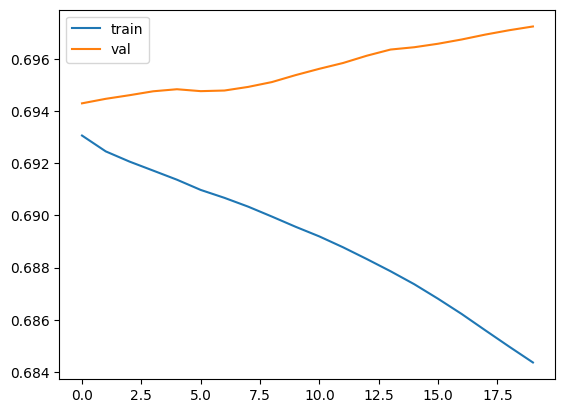

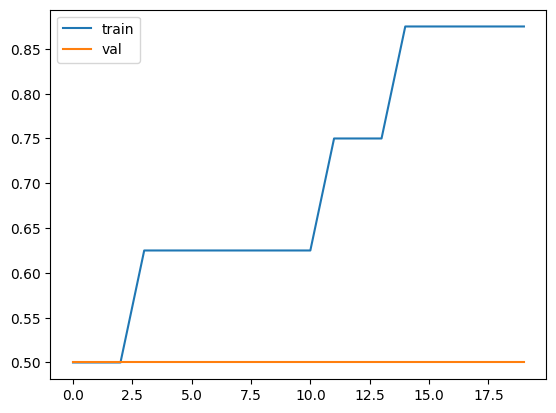

In [13]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

## Predictions

In [14]:
test_sentences = np.array([
    "strong growth and profits",
    "very bad market conditions"
])

test_vec = vectorizer(test_sentences)
preds = model.predict(test_vec)

for s, p in zip(test_sentences, preds):
    print(f"{s} → {p[0]:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
strong growth and profits → 0.493
very bad market conditions → 0.495


# WordPieceTokenizer

## Load pretrained BERT tokenizer (WordPiece)

In [15]:
wp_tokenizer = tokenizer = kh.tokenizers.BertTokenizer.from_preset(
    "bert_base_en_uncased"
)

## Tokenize text

In [16]:
text = ["Deep learning is powerful"]
tokens = wp_tokenizer(texts)
print(tokens)

[[2023, 4518, 2003, 2183, 2039], [2844, 16565, 1998, 3930], [7087, 4509, 11071, 4247], [3006, 3504, 2200, 3893], [2307, 3361, 3463], [2023, 4518, 2003, 12894], [2200, 2919, 16565, 3189], [4562, 4509, 17680, 3805], [3006, 12503, 4803], [3532, 3361, 2836]]


## Inspect vocabulary

In [17]:
vocab = wp_tokenizer.get_vocabulary()
print(len(vocab))
print(vocab[2000:2020])

30522
['to', 'was', 'he', 'is', 'as', 'for', 'on', 'with', 'that', 'it', 'his', 'by', 'at', 'from', 'her', '##s', 'she', 'you', 'had', 'an']


# Byte Pair Encoding (BPE) Tokenizer

## Load tokenizer from a GPT-style preset (BPE)

In [18]:
bpe_tokenizer = kh.tokenizers.Tokenizer.from_preset(
    "gpt2_base_en"
)

## Tokenize text

In [19]:
text = ["Deep learning is powerful"]
tokens = bpe_tokenizer(text)
print(tokens)

[[29744, 4673, 318, 3665]]


In [20]:
vocab = bpe_tokenizer.get_vocabulary()
print("Vocab size:", len(vocab))
print(list(vocab)[2500:2520])

Vocab size: 50257
['icro', 'alt', 'over', 'www', 'That', 'lier', 'Ġeveryone', 'ude', 'Ġpie', 'iddle', 'rael', 'Ġrad', 'Ġblock', 'Ġwalk', 'To', 'ãģ', 'nes', 'ĠAust', 'aul', 'rote']
